# 🌍 Global Demographic & Geographic Pattern Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests 

## 🌐 1. Data Collection

Data was collected using the REST Countries API:

The API returns JSON data which was flattened and converted into a structured pandas DataFrame.

In [2]:
url = "https://restcountries.com/v3.1/all?fields=name,population,area,region,subregion,capital,independent"

In [3]:
response = requests.get(url)

In [4]:
data = response.json()

In [5]:
print(len(data))

250


## 🧹 3. Data Cleaning & Preparation

In [6]:
countries = []

In [7]:
for country in data:
    countries.append({
        "name": country.get("name", {}).get("common"),
        "population": country.get("population"),
        "area": country.get("area"),
        "region": country.get("region"),
        "subregion": country.get("subregion"),
        "capital": country.get("capital", [None])[0] if country.get("capital") else None,
        "independent": country.get("independent")
    })

In [8]:
df = pd.DataFrame(countries)

In [9]:
df

,name,population,area,region,subregion,capital,independent
0,Vietnam,101343800,331212.0,Asia,South-Eastern Asia,Hanoi,True
1,French Guiana,292354,83534.0,Americas,South America,Cayenne,False
2,Sint Maarten,41349,34.0,Americas,Caribbean,Philipsburg,False
3,British Virgin Islands,39471,151.0,Americas,Caribbean,Road Town,False
4,Papua New Guinea,11781559,462840.0,Oceania,Melanesia,Port Moresby,True
...,...,...,...,...,...,...,...
245,Cuba,9748007,109884.0,Americas,Caribbean,Havana,True
246,France,66351959,543908.0,Europe,Western Europe,Paris,True
247,Suriname,616500,163820.0,Americas,South America,Paramaribo,True
248,Liberia,5248621,111369.0,Africa,Western Africa,Monrovia,True


In [10]:
df.head()

,name,population,area,region,subregion,capital,independent
0,Vietnam,101343800,331212.0,Asia,South-Eastern Asia,Hanoi,True
1,French Guiana,292354,83534.0,Americas,South America,Cayenne,False
2,Sint Maarten,41349,34.0,Americas,Caribbean,Philipsburg,False
3,British Virgin Islands,39471,151.0,Americas,Caribbean,Road Town,False
4,Papua New Guinea,11781559,462840.0,Oceania,Melanesia,Port Moresby,True


In [11]:
df.shape


(250, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         250 non-null    object 
 1   population   250 non-null    int64  
 2   area         250 non-null    float64
 3   region       250 non-null    object 
 4   subregion    250 non-null    object 
 5   capital      246 non-null    object 
 6   independent  250 non-null    bool   
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 12.1+ KB


In [13]:
df.describe()

,population,area
count,2.500000e+02,2.500000e+02
mean,3.207798e+07,6.010389e+05
std,1.319655e+08,1.912575e+06
min,0.000000e+00,4.900000e-01
25%,2.233542e+05,1.194250e+03
50%,5.279123e+06,6.492950e+04
75%,2.037166e+07,3.841505e+05
max,1.417492e+09,1.709825e+07


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

name           0
population     0
area           0
region         0
subregion      0
capital        4
independent    0
dtype: int64

In [16]:
df["capital"] = df["capital"].fillna("Unknown")

In [17]:
df.isnull().sum()

name           0
population     0
area           0
region         0
subregion      0
capital        0
independent    0
dtype: int64

In [18]:
df.to_csv("data/countries_cleaned.csv", index=False)

## 📊 3. Exploratory Data Analysis

In [19]:
df

,name,population,area,region,subregion,capital,independent
0,Vietnam,101343800,331212.0,Asia,South-Eastern Asia,Hanoi,True
1,French Guiana,292354,83534.0,Americas,South America,Cayenne,False
2,Sint Maarten,41349,34.0,Americas,Caribbean,Philipsburg,False
3,British Virgin Islands,39471,151.0,Americas,Caribbean,Road Town,False
4,Papua New Guinea,11781559,462840.0,Oceania,Melanesia,Port Moresby,True
...,...,...,...,...,...,...,...
245,Cuba,9748007,109884.0,Americas,Caribbean,Havana,True
246,France,66351959,543908.0,Europe,Western Europe,Paris,True
247,Suriname,616500,163820.0,Americas,South America,Paramaribo,True
248,Liberia,5248621,111369.0,Africa,Western Africa,Monrovia,True


### 3.1 Regional Population Share

Objective:
To determine which region contributes the most to global population and understand demographic concentration patterns.

In [20]:
region_population = df.groupby("region")["population"].sum().reset_index()

In [21]:
region_population

,region,population
0,Africa,1462464411
1,Americas,1042579783
2,Antarctic,1700
3,Asia,4724731966
4,Europe,741657922
5,Oceania,48059678


In [22]:
total_population = df['population'].sum()

In [23]:
total_population

np.int64(8019495460)

In [24]:
region_population["population_share_%"] = (
    region_population["population"] / total_population
) * 100

In [25]:
region_population = region_population.sort_values(
    by="population", ascending=False)


region_population

,region,population,population_share_%
3,Asia,4724731966,58.915576
0,Africa,1462464411,18.236364
1,Americas,1042579783,13.000566
4,Europe,741657922,9.248187
5,Oceania,48059678,0.599286
2,Antarctic,1700,0.000021


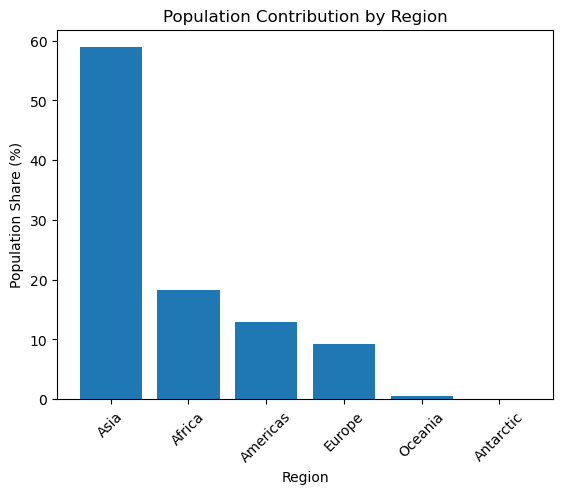

In [26]:
plt.figure()
plt.bar(region_population["region"], region_population["population_share_%"])
plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Population Share (%)")
plt.title("Population Contribution by Region")
plt.show()

**Insight:**

Asia contributes approximately 60% of the global population, indicating strong demographic concentration within a single region.

### 3.2 Relationship Between Area and Population

Objective:
To examine whether land area influences population size.

In [27]:
df[["area", "population"]].corr()

,area,population
area,1.000000,0.402275
population,0.402275,1.000000


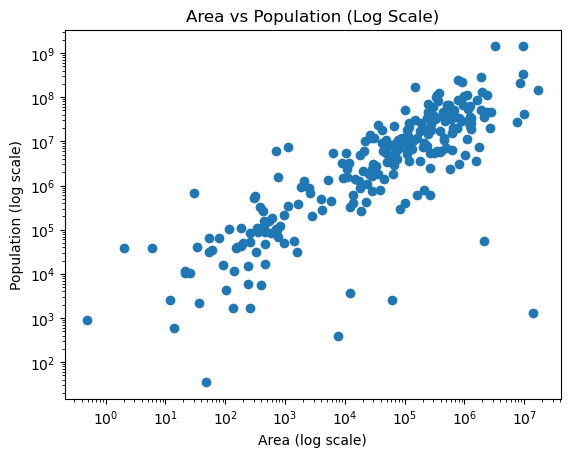

In [28]:
plt.figure()
plt.scatter(df["area"], df["population"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Area (log scale)")
plt.ylabel("Population (log scale)")
plt.title("Area vs Population (Log Scale)")
plt.show()

**Insight:**

The correlation coefficient (~0.40) indicates a moderate positive relationship.  
Land area alone does not strongly determine population size.

### 3.3 Population Density Analysis

Objective:
To identify highly concentrated countries and analyze global density distribution.

In [29]:
df["population_density"] = df["population"]/df["area"]

In [30]:
df[["name", "population_density"]].head()

,name,population_density
0,Vietnam,305.978648
1,French Guiana,3.499820
2,Sint Maarten,1216.147059
3,British Virgin Islands,261.397351
4,Papua New Guinea,25.454928


In [31]:
top_density = df.sort_values(
    by="population_density",ascending = False
).head(10)

top_density[["name","population_density"]]

,name,population_density
209,Macau,22863.333333
32,Monaco,19021.287129
43,Singapore,8605.915493
185,Hong Kong,6818.387681
76,Gibraltar,6333.333333
194,Bahrain,2084.515033
123,Malta,1817.246835
161,Vatican City,1800.000000
165,Maldives,1717.106667
2,Sint Maarten,1216.147059


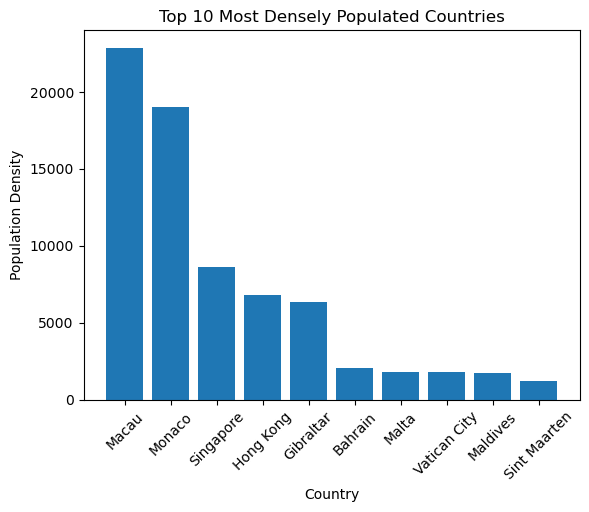

In [32]:
plt.figure()
plt.bar(top_density["name"], top_density["population_density"])
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Population Density")
plt.title("Top 10 Most Densely Populated Countries")
plt.show()

**Insight:**

Small territories tend to have extremely high population density due to limited land area and urban concentration.

### 3.4 Independence-Based Comparison

Objective:
To compare demographic patterns between independent and non-independent territories.

In [33]:
df["independent"].value_counts()

independent
True     195
False     55
Name: count, dtype: int64

In [34]:
independent_stats = (
    df.groupby("independent")[["population", "population_density"]]
    .mean()
    .reset_index()
)

independent_stats

,independent,population,population_density
0,False,8.193481e+05,881.508383
1,True,4.089452e+07,311.541539


In [35]:
df_clean = df[df["independent"].notna()]

In [36]:
independent_median = (
    df_clean.groupby("independent")[["population", "population_density"]]
    .median()
    .reset_index()
)

independent_median

,independent,population,population_density
0,False,41349.0,97.50000
1,True,9109280.0,87.94076


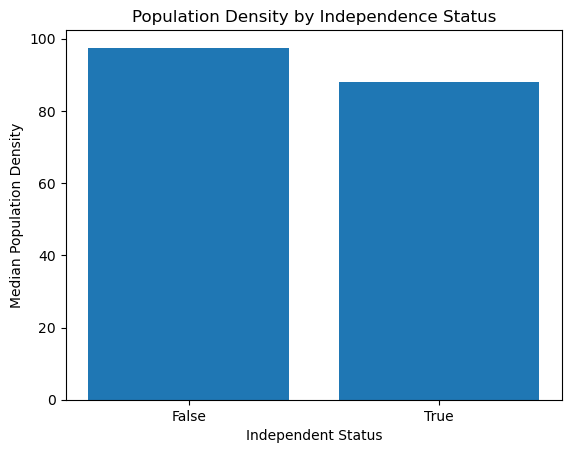

In [37]:
density_compare = (
    df_clean.groupby("independent")["population_density"]
    .median()
    .reset_index()
)

plt.figure()
plt.bar(density_compare["independent"].astype(str),
        density_compare["population_density"])

plt.xlabel("Independent Status")
plt.ylabel("Median Population Density")
plt.title("Population Density by Independence Status")
plt.show()

**Insight:**

Non-independent territories exhibit higher median population density, likely due to their smaller land area and urbanized characteristics.

##  📈4. Key Findings

- Asia dominates global population distribution.
- Area and population show a moderate positive correlation.
- Population density is heavily right-skewed.
- Smaller territories tend to have higher density.
- Non-independent regions exhibit higher median density.